Loaded 47,354 rows × 27 columns
Mean range: [-0.000, 0.000]  (expected ~0)
Std  range: [1.000, 1.000]   (expected ~1)

Plotting 26 normalised features in a 7×4 grid


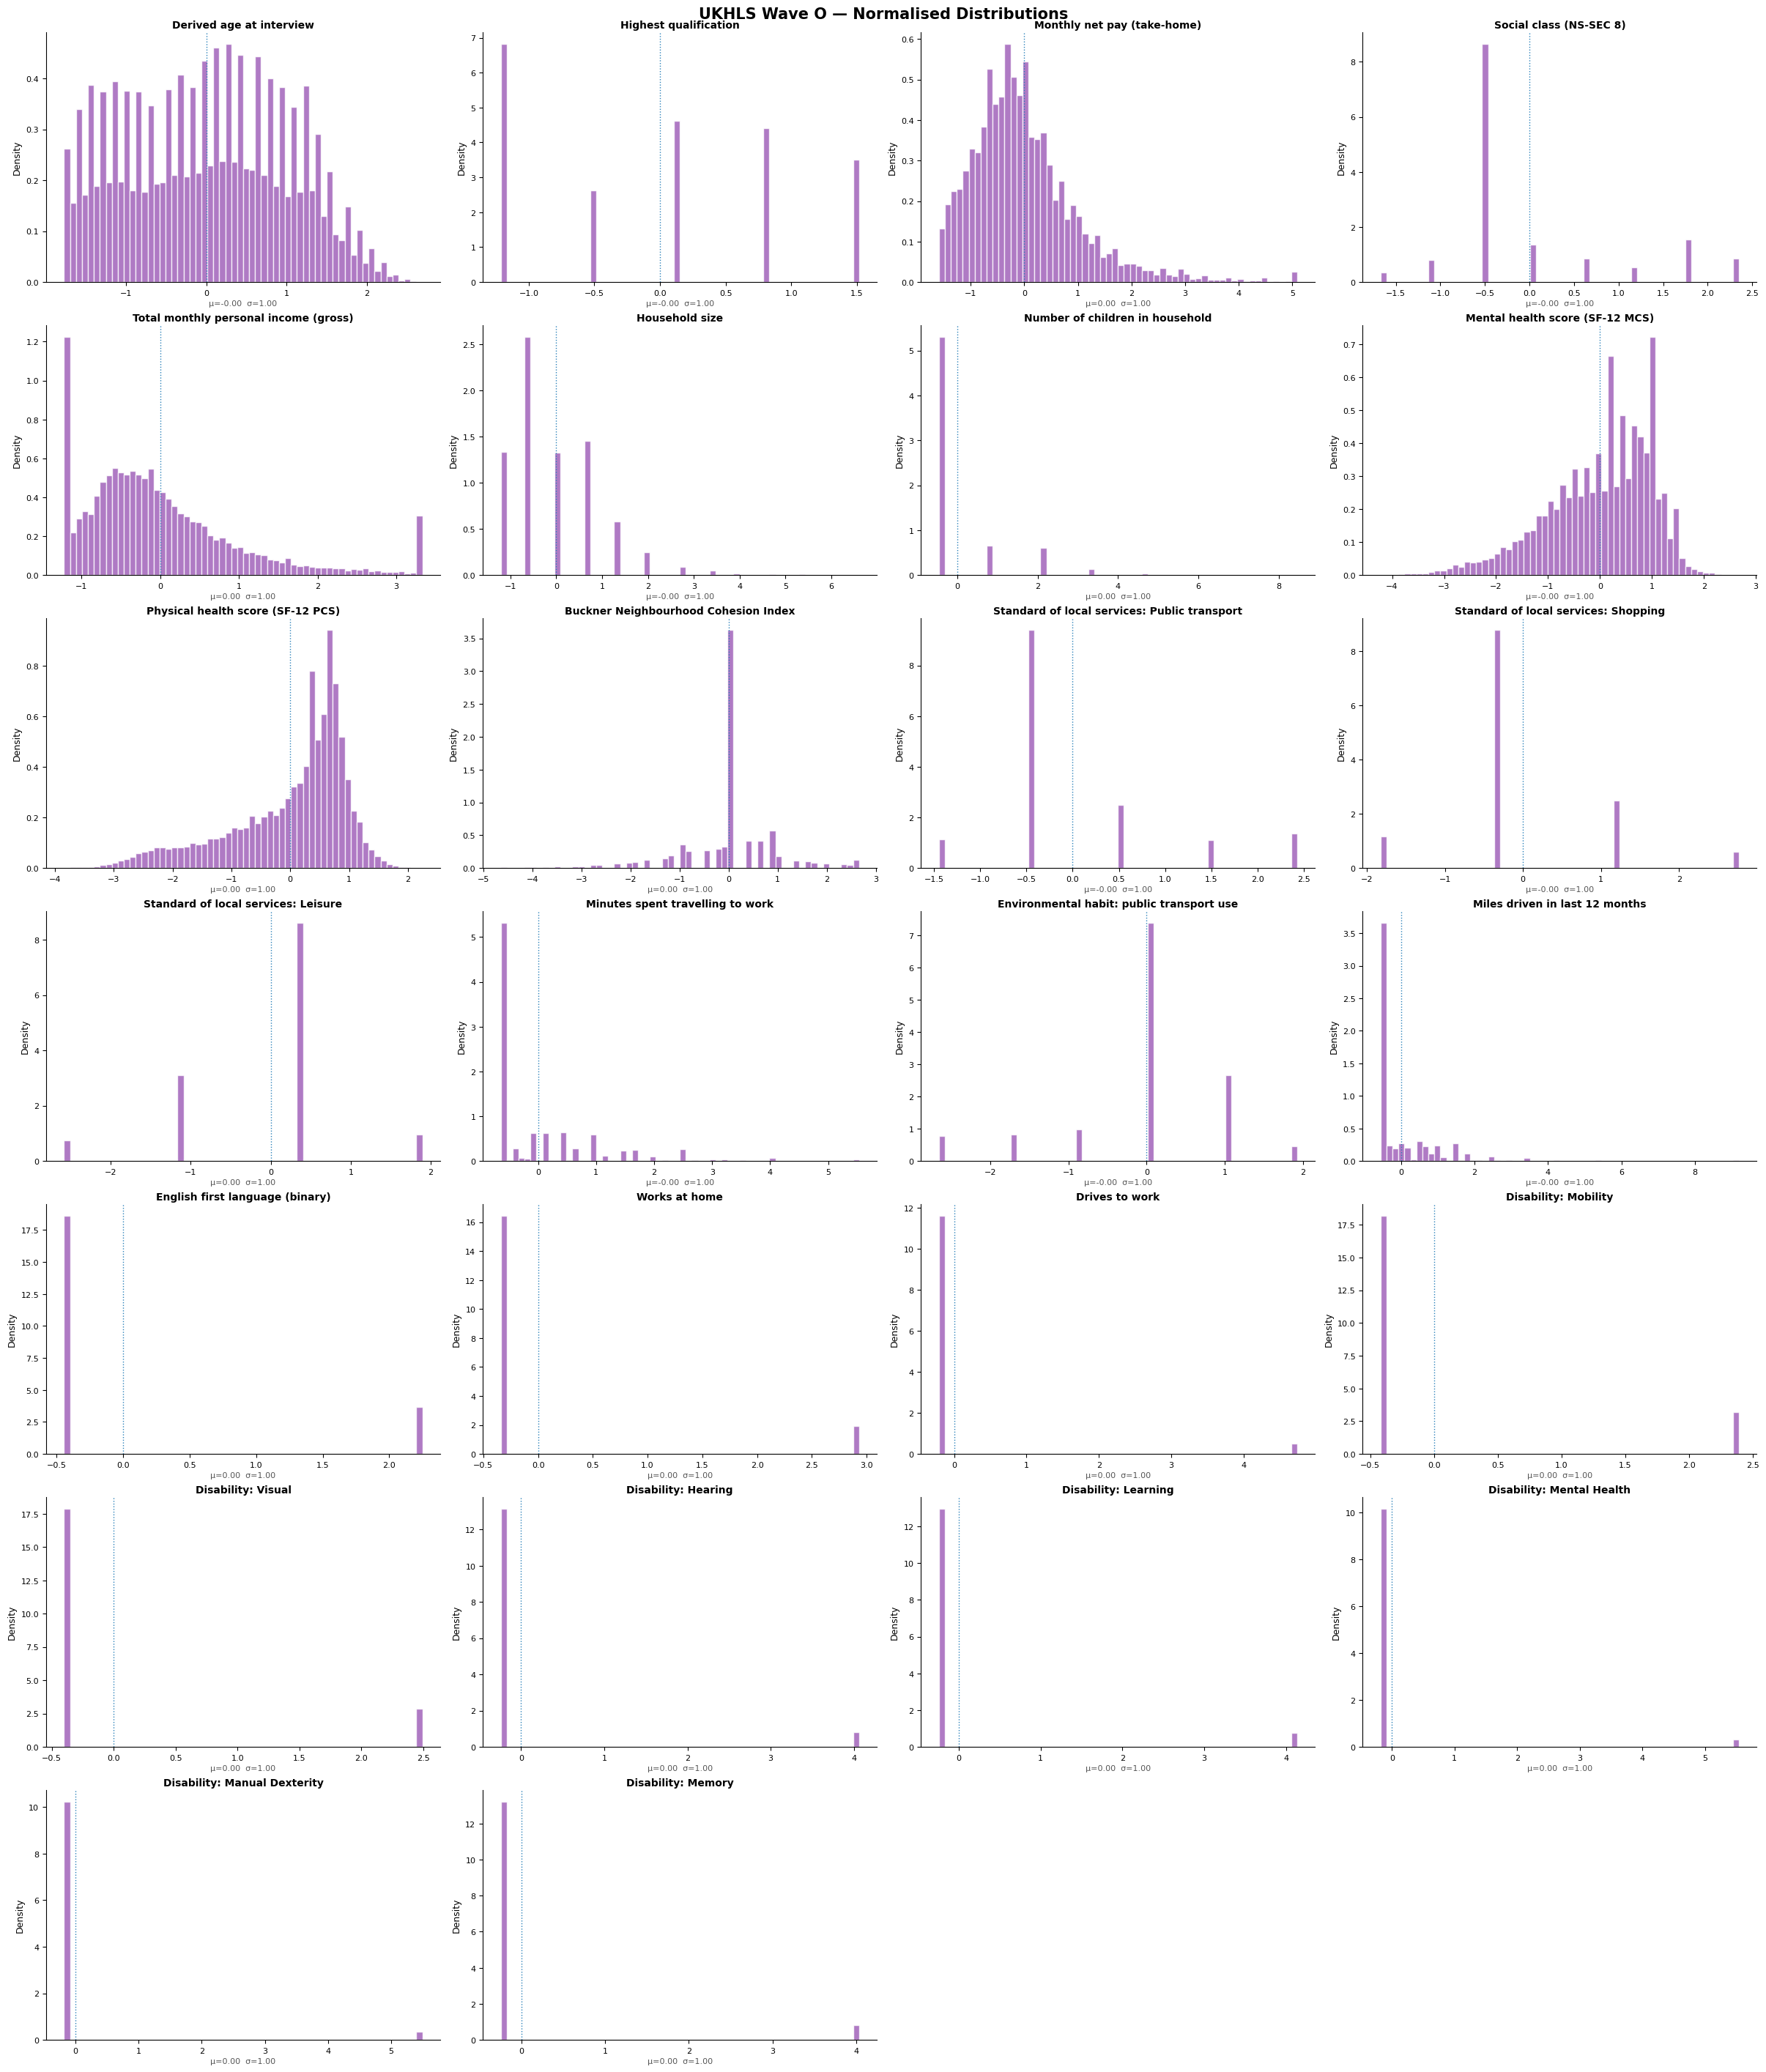

Saved to ../data/5_normalise_ukhls/normalised_distributions.png


In [3]:
# 5_visualise_normalise.ipynb
#
# Plots the Z-score normalised distributions for every cluster feature.
# All columns should be approximately N(0,1) after step 5.
# Use this to validate 5_normalise_ukhls.ipynb output.

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import importlib
import data_processing.ukhls_variables as _ukhls_vars
importlib.reload(_ukhls_vars)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data_processing.ukhls_variables import VARIABLES, CLUSTER_VARS

# ── Config ────────────────────────────────────────────────────────────────────
WAVE         = "o"
PICKLE_PATH  = "../data/5_normalise_ukhls/normalized.pkl"
COLS_PER_ROW = 4
HIST_COLOR   = "#9b59b6"

# ── Load ─────────────────────────────────────────────────────────────────────
if not os.path.exists(PICKLE_PATH):
    raise FileNotFoundError(f"{PICKLE_PATH} not found — run 5_normalise_ukhls.ipynb first.")

df = pd.read_pickle(PICKLE_PATH)
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")

feature_cols = [c for c in df.columns if c != 'pidp']
means = df[feature_cols].mean()
stds  = df[feature_cols].std()
print(f"Mean range: [{means.min():.3f}, {means.max():.3f}]  (expected ~0)")
print(f"Std  range: [{stds.min():.3f}, {stds.max():.3f}]   (expected ~1)")

# ── Build plot specs ──────────────────────────────────────────────────────────
plot_specs = []
for base_code in CLUSTER_VARS:
    col = f"{WAVE}_{base_code}"
    if col not in df.columns:
        continue
    var_def = VARIABLES.get(base_code, {})
    plot_specs.append(dict(
        col   = col,
        label = var_def.get("label", base_code),
    ))

n_plots = len(plot_specs)
n_cols  = COLS_PER_ROW
n_rows  = (n_plots + n_cols - 1) // n_cols
print(f"\nPlotting {n_plots} normalised features in a {n_rows}×{n_cols} grid")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows), constrained_layout=True)
axes_flat = axes.flatten()

for idx, spec in enumerate(plot_specs):
    ax   = axes_flat[idx]
    col  = spec["col"]
    vals = df[col].dropna()

    ax.hist(vals, bins=60, color=HIST_COLOR, edgecolor="white", density=True, alpha=0.8)
    ax.axvline(vals.mean(), color="#2980b9", linestyle=":", linewidth=1)

    mu, sigma = vals.mean(), vals.std()
    subtitle = f"μ={mu:.2f}  σ={sigma:.2f}"

    ax.set_title(spec["label"], fontsize=10, fontweight="bold", pad=4)
    ax.set_xlabel(subtitle, fontsize=8, labelpad=3, color="#555")
    ax.set_ylabel("Density", fontsize=9)
    ax.tick_params(axis="both", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

for unused in axes_flat[n_plots:]:
    unused.set_visible(False)

fig.suptitle(
    f"UKHLS Wave {WAVE.upper()} — Normalised Distributions",
    fontsize=15, fontweight="bold", y=1.005,
)
plt.savefig("../data/5_normalise_ukhls/normalised_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to ../data/5_normalise_ukhls/normalised_distributions.png")
